In [1]:
#!pip install pymystem3
!pip uninstall pymorphy2 -y
!pip install pymorphy3
!pip install langdetect

In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Список всех файлов, которые нужно объединить
file_list = glob.glob('final_*.csv')

# Объединяем все файлы в один DataFrame
final_data = pd.concat([pd.read_csv(file) for file in file_list], ignore_index=True)

# Сохраняем результат в новый файл
final_data.to_csv('final_data.csv', index=False)

In [3]:
final_data = pd.read_csv("final_data.csv")
final_data

,title,text,is_fake
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1
...,...,...,...
80912,Столичная мэрия по ошибке опубликовала персона...,Столичная мэрия по ошибке опубликовала персона...,1
80913,Леонид Якубович станет ведущим российской верс...,Леонид Якубович станет ведущим российской верс...,1
80914,Московский чиновник после получения крупной вз...,Московский чиновник после получения крупной вз...,1
80915,Устроивший пробку контейнеровоз не выпустят из...,Устроивший пробку контейнеровоз не выпустят из...,1


In [4]:
count_0 = (final_data['is_fake'] == 0).sum()
count_1 = (final_data['is_fake'] == 1).sum()

print(f"Количество строк с меткой 0: {count_0}")
print(f"Количество строк с меткой 1: {count_1}")

Количество строк с меткой 0: 47110
Количество строк с меткой 1: 33807


ПРЕДОБРАБОТКА ДАННЫХ

In [6]:
import pymorphy3 as pymorphy2
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from langdetect import detect

# Инициализация (один раз!)
morph = pymorphy2.MorphAnalyzer()
lemmatizer = WordNetLemmatizer()

russian_stopwords = set(stopwords.words('russian'))
english_stopwords = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # Приведение к нижнему регистру и удаление знаков препинания
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Определение языка
    try:
        lang = detect(text)
    except:
        lang = 'en'
    
    words = text.split()
    
    if lang == 'ru':
        # Русская лемматизация через pymorphy3
        words = [w for w in words if w not in russian_stopwords]
        words = [morph.parse(word)[0].normal_form for word in words]
    else:
        # Английская лемматизация
        words = [w for w in words if w not in english_stopwords]
        words = [lemmatizer.lemmatize(w) for w in words]
    
    return ' '.join(words)

# Применение
final_data = final_data.dropna(subset=['text'])
final_data['processed_text'] = final_data['text'].apply(preprocess_text)

C:\Users\user\AppData\Local\Temp\ipykernel_10500\3602926713.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['processed_text'] = final_data['text'].apply(preprocess_text)


In [7]:
final_data

,title,text,is_fake,processed_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1,pope francis used annual christmas day message...
...,...,...,...,...
80912,Столичная мэрия по ошибке опубликовала персона...,Столичная мэрия по ошибке опубликовала персона...,1,столичный мэрия ошибка опубликовать персональн...
80913,Леонид Якубович станет ведущим российской верс...,Леонид Якубович станет ведущим российской верс...,1,леонид якубович стать ведущий российский верси...
80914,Московский чиновник после получения крупной вз...,Московский чиновник после получения крупной вз...,1,московский чиновник получение крупный взятка р...
80915,Устроивший пробку контейнеровоз не выпустят из...,Устроивший пробку контейнеровоз не выпустят из...,1,устроить пробка контейнеровоз выпустить суэцки...


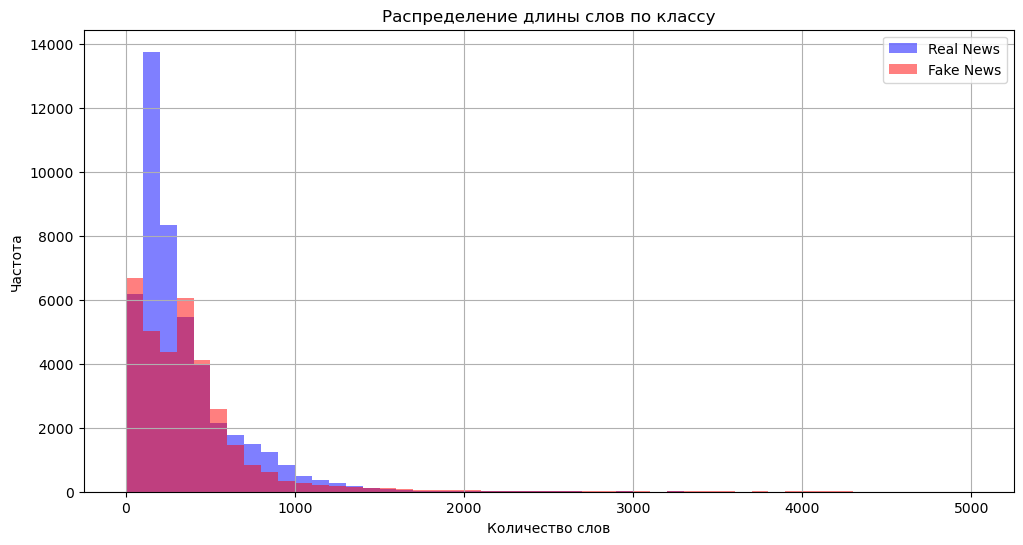

In [8]:
# Удаляем строки с пропущенными значениями в столбце 'text'
data = final_data.dropna(subset=['text'])

# Добавляем столбец с количеством слов в каждом тексте
data['word_count'] = data['text'].apply(lambda x: len(x.split()))

# Разделяем данные по классам
real_news = data[data['is_fake'] == 0]['word_count']
fake_news = data[data['is_fake'] == 1]['word_count']

# Строим гистограммы
plt.figure(figsize=(12, 6))
plt.hist(real_news, bins=50, alpha=0.5, label='Real News', color='blue', range=(0, 5000))
plt.hist(fake_news, bins=50, alpha=0.5, label='Fake News', color='red', range=(0, 5000))

# Добавляем легенду и подписи
plt.title('Распределение длины слов по классу')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Средняя длина текстов
print(f"Средняя длина настоящих новостей: {real_news.mean():.2f} слов")
print(f"Средняя длина фейковых новостей: {fake_news.mean():.2f} слов")

Средняя длина настоящих новостей: 342.28 слов
Средняя длина фейковых новостей: 377.98 слов


МОДЕЛЬ И ТЕСТИРОВАНИЕ

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = final_data['processed_text']
y = final_data['is_fake']

# 2. Разделение на Train, Validation и Test
# Сначала отделяем тестовую выборку (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
# Оставшиеся 85% делим пополам на Train и Validation (получится по 15% и 70% от общего объема)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Размеры выборок:\nTrain: {len(X_train)}\nValidation: {len(X_val)}\nTest: {len(X_test)}\n")

# 3. Векторизация текста
# ВАЖНО: fit_transform вызываем ТОЛЬКО для train, чтобы избежать утечки данных
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

# 4. Обучение модели
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# 5. Оценка на Validation Set (для проверки стабильности и подбора параметров)
print("Результаты на Validation Set:")
y_val_pred = model.predict(X_val_tfidf)
print(classification_report(y_val, y_val_pred))
print(f"Accuracy (Val): {accuracy_score(y_val, y_val_pred):.4f}\n")

# 6. Оценка на Test Set (финальная объективная оценка)
print("Результаты на Test Set:")
y_test_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_test_pred))
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred):.4f}")

Размеры выборок:
Train: 68685
Validation: 6061
Test: 6061

Результаты на Validation Set:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3533
           1       0.97      0.97      0.97      2528

    accuracy                           0.98      6061
   macro avg       0.97      0.97      0.97      6061
weighted avg       0.98      0.98      0.98      6061

Accuracy (Val): 0.9751

Результаты на Test Set:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3534
           1       0.97      0.98      0.97      2527

    accuracy                           0.98      6061
   macro avg       0.98      0.98      0.98      6061
weighted avg       0.98      0.98      0.98      6061

Accuracy (Test): 0.9786


In [11]:
from sklearn.model_selection import cross_validate

# Определяем метрики для кросс-валидации
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Выполняем кросс-валидацию
cv_results = cross_validate(
    model, X_train_tfidf, y_train, cv=5, scoring=scoring
)

# Выводим средние значения метрик
print("Accuracy:", cv_results['test_accuracy'].mean())
print("Precision:", cv_results['test_precision'].mean())
print("Recall:", cv_results['test_recall'].mean())
print("F1-score:", cv_results['test_f1'].mean())
print("ROC AUC:", cv_results['test_roc_auc'].mean())

Accuracy: 0.9726869039819466
Precision: 0.967580674880707
Recall: 0.966901562276022
F1-score: 0.9672399185804427
ROC AUC: 0.9962526563490475


In [12]:
import joblib

# Сохраняем модель и векторизатор
joblib.dump(model, 'model_logreg.pkl')
joblib.dump(vectorizer, 'vectorizer_tfidf.pkl')
print("Модель и векторизатор сохранены в 'model_logreg.pkl' и 'vectorizer_tfidf.pkl'")

Модель и векторизатор сохранены в 'model_logreg.pkl' и 'vectorizer_tfidf.pkl'
